In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

print("Project Root:", PROJECT_ROOT)

csv_files = [
    p for p in PROJECT_ROOT.rglob("*.csv")
    if ".git" not in p.parts
    and ".ipynb_checkpoints" not in p.parts
]

print("\nAvailable CSV files:")

for i, file in enumerate(csv_files, start=1):
    print(i, file)

Project Root: D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Day2_OTT_Content_Analysis

Available CSV files:


In [6]:
import pandas as pd

df = pd.read_csv("D://Veda Internship//Sakshi//Super_Store_DataCleaning//OTT_Streaming_Content_Trend_Analysis_Day31//Day1_OTT_Content_Analysis//Dataset//netflix_titles.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found

Dataset loaded successfully!
Shape: (6234, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [7]:
pip install pandas matplotlib seaborn openpyxl jupyter

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [9]:
sns.set_theme(style="whitegrid")

OUTPUT_PATH = PROJECT_ROOT / "Day2_OTT_Content_Analysis"
CHART_PATH = OUTPUT_PATH / "visualizations"
CHART_PATH.mkdir(parents=True, exist_ok=True)

In [10]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)


In [11]:
column_aliases = {
    "show_id": "content_id",
    "name": "title",
    "genres": "listed_in",
    "genre": "listed_in",
    "production_countries": "country",
    "countries": "country",
    "age_certification": "rating",
    "content_rating": "rating",
    "runtime": "duration",
    "year": "release_year",
    "added_date": "date_added"
}

for old, new in column_aliases.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['content_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [12]:
for col in ["title", "type", "release_year"]:
    if col not in df.columns:
        print(f"Warning: {col} column is missing")

In [13]:
before = len(df)
df = df.drop_duplicates().copy()
print("Duplicate rows removed:", before - len(df))

Duplicate rows removed: 0


In [14]:
for col in [
    "title", "type", "country",
    "rating", "duration", "listed_in"
]:
    if col in df.columns:
        df[col] = (
            df[col].fillna("Unknown")
            .astype(str).str.strip()
        )


In [15]:
if "release_year" in df.columns:
    df["release_year"] = pd.to_numeric(
        df["release_year"], errors="coerce"
    )

In [16]:
if "date_added" in df.columns:
    df["date_added"] = pd.to_datetime(
        df["date_added"], errors="coerce"
    )

In [17]:

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
content_id         0
type               0
title              0
director        1969
cast             570
country            0
date_added       651
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64


In [18]:
print("\nFinal dataset shape:", df.shape)
display(df.head())


Final dataset shape: (6234, 12)


,content_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [19]:
if "listed_in" in df.columns:
    genre_df = df[
        df["listed_in"].ne("Unknown")
    ].copy()

    genre_df["genre"] = genre_df["listed_in"].str.split(",")
    genre_df = genre_df.explode("genre")
    genre_df["genre"] = genre_df["genre"].str.strip()
else:
    genre_df = pd.DataFrame(columns=["title", "genre"])

In [20]:
if "country" in df.columns:
    country_df = df[
        df["country"].ne("Unknown")
    ].copy()

    country_df["country_name"] = country_df["country"].str.split(",")
    country_df = country_df.explode("country_name")
    country_df["country_name"] = country_df["country_name"].str.strip()
else:
    country_df = pd.DataFrame(columns=["title", "country_name"])

In [21]:
if "duration" in df.columns:
    df["duration_value"] = pd.to_numeric(
        df["duration"].str.extract(r"(\d+)")[0],
        errors="coerce"
    )
else:
    df["duration_value"] = pd.NA

In [22]:
print("Genre records:", len(genre_df))
print("Country records:", len(country_df))

display(genre_df.head())
display(country_df.head())

Genre records: 13670
Country records: 7182


,content_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,Children & Family Movies
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,Comedies
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,Stand-Up Comedy
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",Kids' TV
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,Kids' TV


,content_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,country_name
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,United States
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,India
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,South Korea
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,China
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,United Kingdom


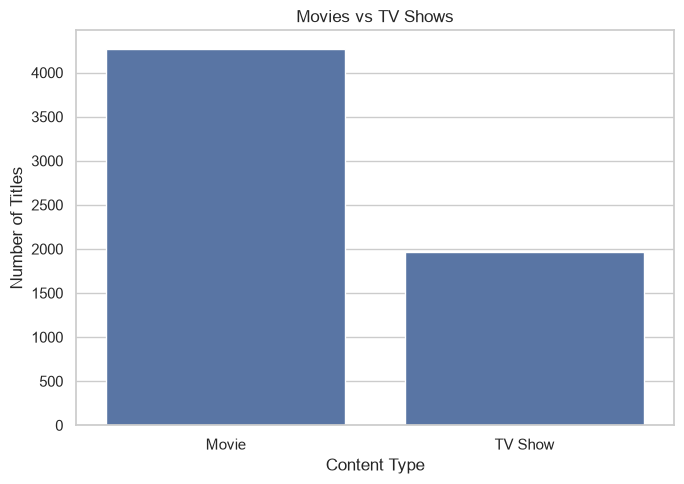

,total_titles
type,
Movie,4265
TV Show,1969


In [23]:
# Chart 1 — Movies vs TV Shows
if "type" in df.columns:
    counts = df["type"].value_counts()

    plt.figure(figsize=(7, 5))
    sns.barplot(x=counts.index, y=counts.values)

    plt.title("Movies vs TV Shows")
    plt.xlabel("Content Type")
    plt.ylabel("Number of Titles")
    plt.tight_layout()

    plt.savefig(CHART_PATH / "01_content_type.png", dpi=150)
    plt.show()

    display(counts.rename("total_titles").to_frame())

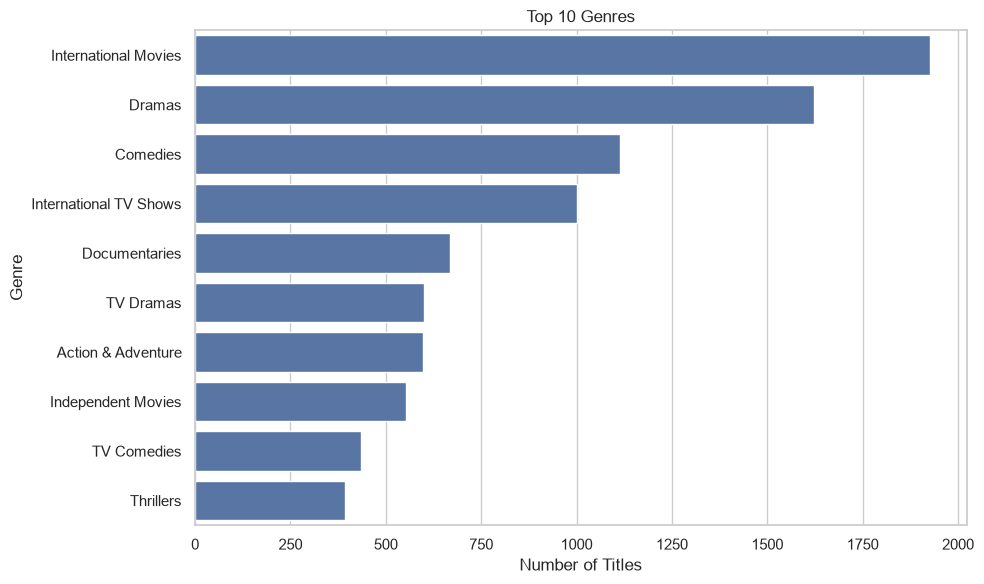

,total_titles
genre,
International Movies,1927
Dramas,1623
Comedies,1113
International TV Shows,1001
Documentaries,668
TV Dramas,599
Action & Adventure,597
Independent Movies,552
TV Comedies,436


In [24]:
# Chart 2 — Top 10 genres
genre_counts = genre_df["genre"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()

plt.savefig(CHART_PATH / "02_top_genres.png", dpi=150)
plt.show()

display(genre_counts.rename("total_titles").to_frame())

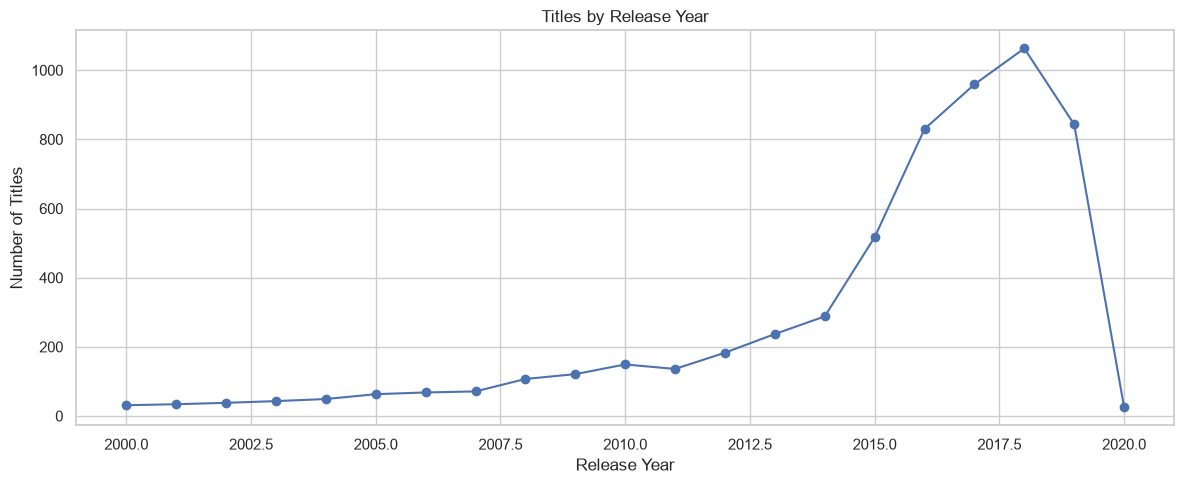

,total_titles
release_year,
2000,31
2001,34
2002,38
2003,43
2004,49
2005,63
2006,68
2007,71
2008,107


In [25]:
# Chart 3 — Release-year trend
yearly_counts = (
    df.dropna(subset=["release_year"])
    .groupby("release_year")
    .size()
    .sort_index()
)

yearly_counts = yearly_counts.loc[
    (yearly_counts.index >= 2000) &
    (yearly_counts.index <= 2025)
]

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker="o")

plt.title("Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()

plt.savefig(CHART_PATH / "03_release_year.png", dpi=150)
plt.show()

display(yearly_counts.rename("total_titles").to_frame())

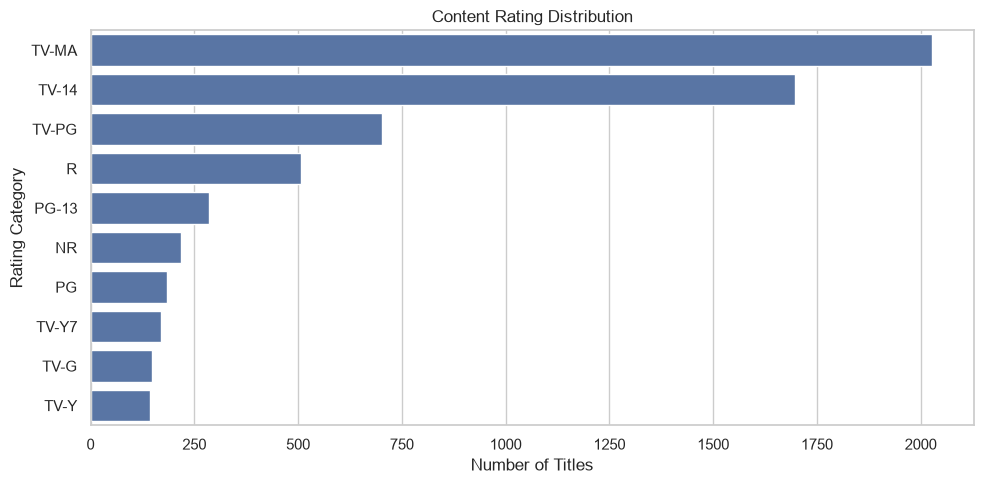

,total_titles
rating,
TV-MA,2027
TV-14,1698
TV-PG,701
R,508
PG-13,286
NR,218
PG,184
TV-Y7,169
TV-G,149


In [26]:
# Chart 4 — Content rating distribution
if "rating" in df.columns:
    rating_counts = (
        df.loc[df["rating"].ne("Unknown"), "rating"]
        .value_counts().head(10)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=rating_counts.values, y=rating_counts.index)

    plt.title("Content Rating Distribution")
    plt.xlabel("Number of Titles")
    plt.ylabel("Rating Category")
    plt.tight_layout()

    plt.savefig(CHART_PATH / "04_rating_distribution.png", dpi=150)
    plt.show()

    display(rating_counts.rename("total_titles").to_frame())
else:
    print("Rating column unavailable in this dataset.")

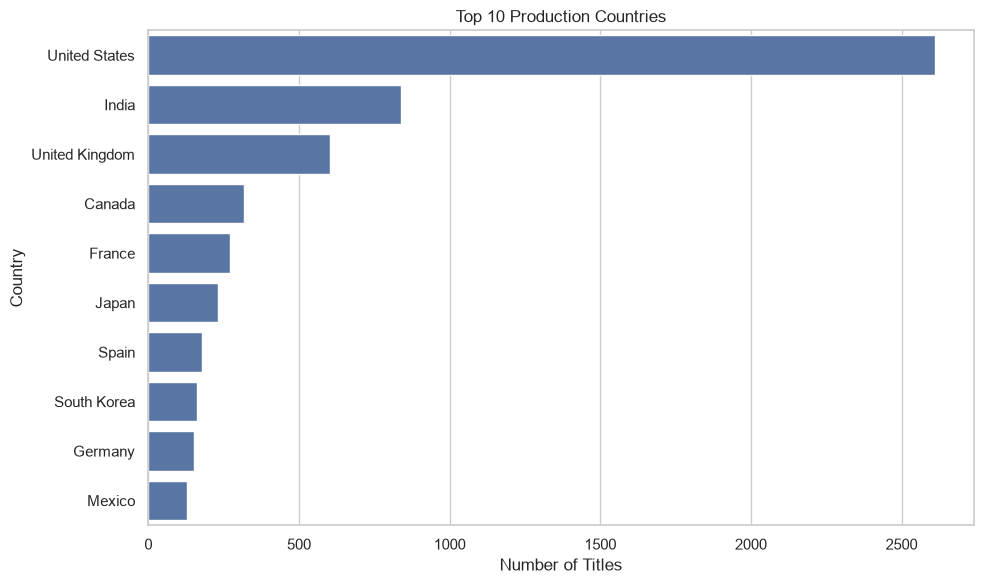

,total_titles
country_name,
United States,2610
India,838
United Kingdom,602
Canada,318
France,271
Japan,231
Spain,178
South Korea,162
Germany,151


In [27]:
# Chart 5 — Top 10 production countries
country_counts = (
    country_df["country_name"]
    .replace("", pd.NA)
    .dropna()
    .value_counts().head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)

plt.title("Top 10 Production Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(CHART_PATH / "05_country_mix.png", dpi=150)
plt.show()

display(country_counts.rename("total_titles").to_frame())

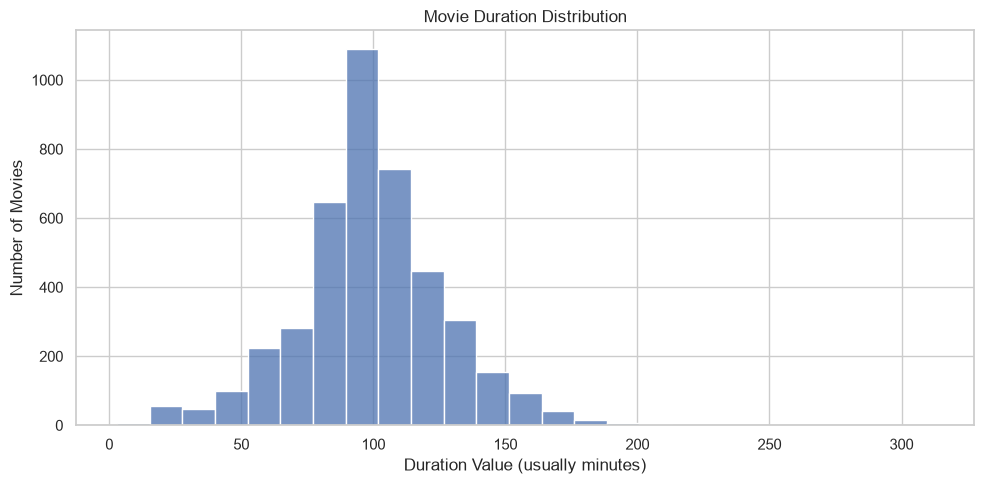

count    4265.000000
mean       99.100821
std        28.074857
min         3.000000
25%        86.000000
50%        98.000000
75%       115.000000
max       312.000000
Name: duration_value, dtype: float64


In [28]:
#Chart 6 — Duration distribution
duration_data = df.dropna(subset=["duration_value"]).copy()

if "type" in duration_data.columns:
    # Netflix-style duration: movie duration minutes
    # किंवा TV seasons. वेगवेगळे units एकत्र plot करू नको.
    movie_durations = duration_data[
        (duration_data["type"] == "Movie") &
        (duration_data["duration_value"] > 0)
    ]

    if not movie_durations.empty:
        plt.figure(figsize=(10, 5))
        sns.histplot(
            data=movie_durations,
            x="duration_value",
            bins=25
        )

        plt.title("Movie Duration Distribution")
        plt.xlabel("Duration Value (usually minutes)")
        plt.ylabel("Number of Movies")
        plt.tight_layout()

        plt.savefig(CHART_PATH / "06_movie_duration.png", dpi=150)
        plt.show()

        print(movie_durations["duration_value"].describe())
    else:
        print("No numeric movie durations available.")
else:
    print("Content type unavailable; duration chart needs review.")

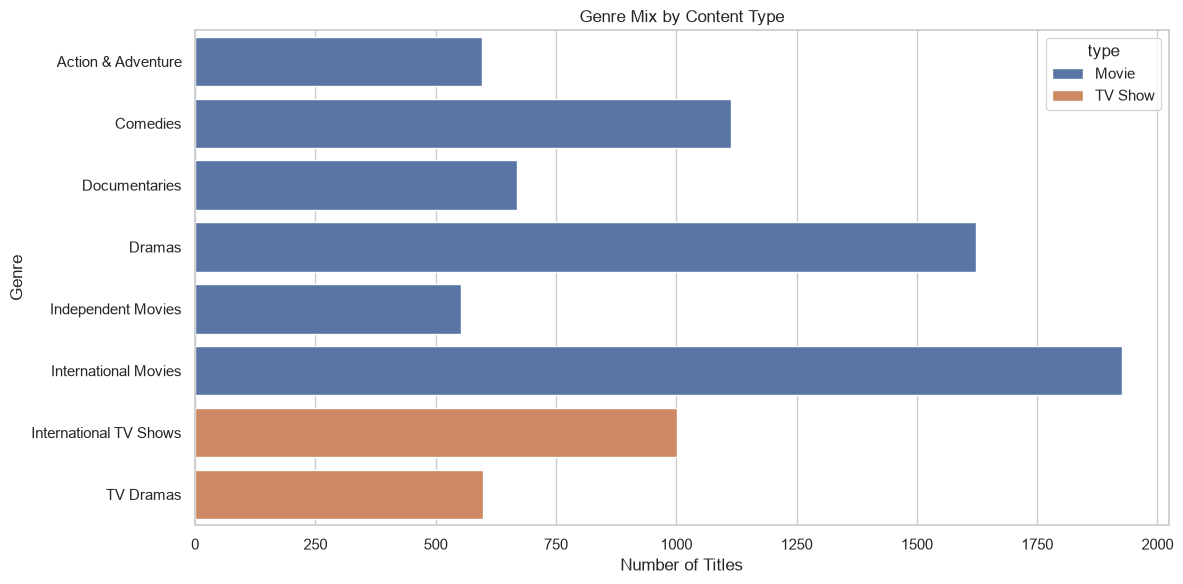

In [29]:
# Bonus Chart 7 — Genre by content type
if "type" in genre_df.columns and not genre_df.empty:
    top_genre_names = genre_df["genre"].value_counts().head(8).index

    genre_type = (
        genre_df[genre_df["genre"].isin(top_genre_names)]
        .groupby(["genre", "type"])
        .size()
        .reset_index(name="total_titles")
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=genre_type,
        x="total_titles",
        y="genre",
        hue="type"
    )

    plt.title("Genre Mix by Content Type")
    plt.xlabel("Number of Titles")
    plt.ylabel("Genre")
    plt.tight_layout()

    plt.savefig(CHART_PATH / "07_genre_by_type.png", dpi=150)
    plt.show()

In [30]:
# Prepare summary tables

# Content type summary
if "type" in df.columns:
    content_summary = (
        df["type"].value_counts()
        .rename_axis("content_type")
        .reset_index(name="total_titles")
    )
else:
    content_summary = pd.DataFrame()

# Genre summary
genre_summary = (
    genre_df["genre"].value_counts()
    .rename_axis("genre")
    .reset_index(name="total_titles")
)

# Release year summary
year_summary = (
    df.dropna(subset=["release_year"])
    .groupby("release_year")
    .size()
    .reset_index(name="total_titles")
    .sort_values("release_year")
)

# Country summary
country_summary = (
    country_df["country_name"].value_counts()
    .rename_axis("country")
    .reset_index(name="total_titles")
)

# Rating summary
if "rating" in df.columns:
    rating_summary = (
        df[df["rating"] != "Unknown"]["rating"]
        .value_counts()
        .rename_axis("rating")
        .reset_index(name="total_titles")
    )
else:
    rating_summary = pd.DataFrame()

# Duration summary
duration_summary = duration_data[
    ["title", "type", "duration", "duration_value"]
].copy() if "duration" in df.columns and "type" in df.columns else pd.DataFrame()

print("Content summary")
display(content_summary)

print("Top 10 genres")
display(genre_summary.head(10))

print("Top 10 countries")
display(country_summary.head(10))

Content summary


,content_type,total_titles
0,Movie,4265
1,TV Show,1969


Top 10 genres


,genre,total_titles
0,International Movies,1927
1,Dramas,1623
2,Comedies,1113
3,International TV Shows,1001
4,Documentaries,668
5,TV Dramas,599
6,Action & Adventure,597
7,Independent Movies,552
8,TV Comedies,436
9,Thrillers,392


Top 10 countries


,country,total_titles
0,United States,2610
1,India,838
2,United Kingdom,602
3,Canada,318
4,France,271
5,Japan,231
6,Spain,178
7,South Korea,162
8,Germany,151
9,Mexico,129


In [31]:
# Create the Excel workbook

excel_path = OUTPUT_PATH / "content_analysis.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df.head(1000).to_excel(
        writer, sheet_name="Cleaned_Data_Sample", index=False
    )

    content_summary.to_excel(
        writer, sheet_name="Content_Summary", index=False
    )

    genre_summary.to_excel(
        writer, sheet_name="Genre_Analysis", index=False
    )

    year_summary.to_excel(
        writer, sheet_name="Year_Analysis", index=False
    )

    country_summary.to_excel(
        writer, sheet_name="Country_Analysis", index=False
    )

    rating_summary.to_excel(
        writer, sheet_name="Rating_Analysis", index=False
    )

    duration_summary.to_excel(
        writer, sheet_name="Duration_Analysis", index=False
    )

print("Excel workbook saved:", excel_path)

Excel workbook saved: D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Day2_OTT_Content_Analysis\Day2_OTT_Content_Analysis\content_analysis.xlsx


In [2]:


import pandas as pd

df = pd.read_csv("D://Veda Internship//Sakshi//Super_Store_DataCleaning//OTT_Streaming_Content_Trend_Analysis_Day31//Day1_OTT_Content_Analysis//Dataset//netflix_titles.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found

Dataset loaded successfully!
Shape: (6234, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [1]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="ott_content_analysis"
)

cursor = conn.cursor()

print("MySQL connection successful!")

MySQL connection successful!


In [3]:
cursor.execute("DROP TABLE IF EXISTS ott_titles")

cursor.execute("""
    CREATE TABLE ott_titles (
        show_id VARCHAR(20),
        type VARCHAR(20),
        title VARCHAR(500),
        director TEXT,
        cast TEXT,
        country TEXT,
        date_added VARCHAR(50),
        release_year INT,
        rating VARCHAR(20),
        duration VARCHAR(50),
        listed_in TEXT,
        description TEXT
    )
""")
print("Table created successfully!")

Table created successfully!


In [4]:
df = df.astype(object).where(pd.notna(df), None)

In [5]:

insert_query = """
INSERT INTO ott_titles
(
    show_id,
    type,
    title,
    director,
    cast,
    country,
    date_added,
    release_year,
    rating,
    duration,
    listed_in,
    description
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

batch_size = 500

for start in range(0, len(df), batch_size):

    batch = df.iloc[start:start + batch_size]

    rows = [
        tuple(row)
        for row in batch.itertuples(index=False, name=None)
    ]

    cursor.executemany(insert_query, rows)

    conn.commit()

    print(
        f"Inserted {min(start + batch_size, len(df))} / {len(df)} rows"
    )

print("All data inserted successfully!")

Inserted 500 / 6234 rows
Inserted 1000 / 6234 rows
Inserted 1500 / 6234 rows
Inserted 2000 / 6234 rows
Inserted 2500 / 6234 rows
Inserted 3000 / 6234 rows
Inserted 3500 / 6234 rows
Inserted 4000 / 6234 rows
Inserted 4500 / 6234 rows
Inserted 5000 / 6234 rows
Inserted 5500 / 6234 rows
Inserted 6000 / 6234 rows
Inserted 6234 / 6234 rows
All data inserted successfully!


In [6]:
cursor.execute("SELECT COUNT(*) FROM ott_titles")

result = cursor.fetchone()

print("Total rows in MySQL:", result[0])

Total rows in MySQL: 6234


In [7]:
cursor.close()
conn.close()

print("Connection closed.")

Connection closed.
